In [1]:
import numpy as np

np.random.seed(42)

class DenseLayer:
    def __init__(self, units=1, activation='relu'):
        self.units = units
        self.activation = activation.lower()
        self.w = None
        self.b = None
        self.input = None
        self.z = None

    def init_weights(self, fan_in):
      if self.activation in ['relu', 'leaky_relu']:
        std = np.sqrt(2.0 / fan_in)
      else:
        std = np.sqrt(1.0 / fan_in)

      self.w = np.random.normal(0.0, std, (fan_in, self.units))
      self.b = np.zeros(self.units)


    def forward(self, x):
        if self.w is None:
          self.init_weights(x.shape[-1])

        self.z = x @ self.w + self.b

        if self.activation == 'relu':
            return np.maximum(0, self.z)

        elif self.activation == 'leaky_relu':
            return np.maximum(0.01 * self.z, self.z)

        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-self.z))

        elif self.activation == 'tanh':
            return np.tanh(self.z)

        elif self.activation == 'softmax':
            exp_z = np.exp(self.z - np.max(self.z, axis=1, keepdims=True))
            return exp_z / np.sum(exp_z, axis=1, keepdims=True)

        elif self.activation == 'linear':
            return self.z

        else:
            raise ValueError(f"Неизвестная активация: {self.activation}")

    def derivative(self, a):
        if self.activation == 'relu':
            return (self.z > 0).astype(float)

        elif self.activation == 'leaky_relu':
            return (self.z > 0).astype(float) + 0.01 * (self.z <= 0).astype(float)

        elif self.activation == 'sigmoid':
            return a * (1 - a)

        elif self.activation == 'tanh':
            return 1 - a**2

        elif self.activation == 'linear':
            return np.ones_like(a)

        elif self.activation == 'softmax':
            return np.ones_like(a)

        return np.ones_like(a)


class Input:
    def __init__(self, shape=None):
        self.shape = shape

    def forward(self, x):
        if self.shape is not None:
            expected = self.shape if isinstance(self.shape, tuple) else (self.shape,)
            if x.shape[1:] != expected:
                x = x.reshape((x.shape[0],) + expected)
        return x


class Dropout:
  def __init__(self, rate=0.5):
    self.rate = rate
    self.mask = None
    self.training = True

  def forward(self, x):
    if not self.training:
      return x
    self.mask = (np.random.rand(*x.shape) > self.rate) / (1 - self.rate)
    return x * self.mask


class Sequential:
    def __init__(self, layers):
        self.layers = layers
        self.history = []
        self.loss_fn = None
        self.loss_deriv = None
        self.l1 = 0
        self.l2 = 0

    def compile(self, loss='mse', l1=0.0, l2=0.0):
      self.l1 = l1
      self.l2 = l2
      self.loss = loss.lower()

      if self.loss == 'mse':
        self.loss_fn = lambda y, p: np.mean((p - y) ** 2)
        self.loss_deriv = lambda y, p: (p - y)

      elif self.loss == 'mae':
        self.loss_fn = lambda y, p: np.mean(np.abs(p - y))
        self.loss_deriv = lambda y, p: np.sign(p - y)

      elif self.loss == 'binary_crossentropy':
        eps = 1e-8
        self.loss_fn = lambda y, p: -np.mean(
            y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)
        )
        self.loss_deriv = lambda y, p: (p - y)

      elif self.loss == 'categorical_crossentropy':
        eps = 1e-8
        self.loss_fn = lambda y, p: -np.mean(np.sum(y * np.log(p + eps), axis=1))
        self.loss_deriv = lambda y, p: (p - y)

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def fit(self, x_input, y_input, epochs=100, alpha=0.001, batch_size=32,
            clip_value=5.0, adaptive_alpha=False, Ee=1e-3):
        x_input = np.asarray(x_input, dtype=np.float32)
        y_input = np.asarray(y_input, dtype=np.float32).reshape(-1, 1)

        if y_input.ndim == 1:
          y_input = y_input.reshape(-1, 1)

        n_samples = x_input.shape[0]
        self.history = []

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            x_shuffled = x_input[indices]
            y_shuffled = y_input[indices]

            epoch_loss = 0

            for i in range(0, n_samples, batch_size):
                x = x_shuffled[i:i+batch_size]
                y = y_shuffled[i:i+batch_size]

                if adaptive_alpha:
                  alpha_t = 1.0 / (1 + np.sum(x ** 2))
                else:
                  alpha_t = alpha

                activations = [x]
                for layer in self.layers:
                    if isinstance(layer, Dropout):
                        layer.training = True
                    activations.append(layer.forward(activations[-1]))

                pred = activations[-1]

                loss = self.loss_fn(y, pred)

                reg = 0
                for layer in self.layers:
                  if isinstance(layer, DenseLayer):
                    reg += self.l2 * np.mean(layer.w ** 2) + self.l1 * np.mean(np.abs(layer.w))

                loss += reg
                epoch_loss += loss

                # Обратное распространение
                delta = self.loss_deriv(y, pred)
                for l in range(len(self.layers) - 1, -1, -1):
                    layer = self.layers[l]

                    if isinstance(layer, Input):
                        continue

                    if isinstance(layer, Dropout):
                        delta *= layer.mask
                        continue

                    a_prev = activations[l]
                    da = layer.derivative(activations[l+1])
                    if da is not None:
                      delta *= da

                    grad_w = (a_prev.T @ delta) / x.shape[0]
                    grad_b = np.mean(delta, axis=0)

                    if self.l2:
                      grad_w += 2 * self.l2 * layer.w
                    if self.l1:
                      grad_w += self.l1 * np.sign(layer.w)

                    grad_w = np.clip(grad_w, -clip_value, clip_value)
                    grad_b = np.clip(grad_b, -clip_value, clip_value)

                    layer.w -= alpha_t * grad_w
                    layer.b -= alpha_t * grad_b

                    delta = delta @ layer.w.T

            epoch_loss /= (n_samples // batch_size + 1)
            self.history.append(epoch_loss)

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:4d} | {self.loss} = {epoch_loss:.6f}")

            if epoch_loss <= Ee:
              print(f"Достигнут критерий остановки: {epoch_loss} <= {Ee}")
              break

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)

        if X.ndim == 1:
            X = X.reshape(1,-1)

        for layer in self.layers:
            if isinstance(layer, Dropout):
                layer.training = False

        return self.forward(X)


    def evaluate(self, X, Y):
      if Y.ndim == 1:
          Y = Y.reshape(-1, 1)

      preds = self.forward(X)

      loss = None
      if self.loss_fn is not None:
          loss = self.loss_fn(Y, preds)

      last_activation = getattr(self.layers[-1], "activation_name", None)

      if last_activation == "sigmoid":
          y_hat = (preds >= 0.5).astype(np.float32)
          acc = np.mean(y_hat == Y)
      else:
          acc = None

      return loss, acc

In [3]:
import itertools

X_full = np.array(list(itertools.product([0, 1], repeat=6)), dtype=np.float32)
Y_full = np.array([1.0 if sum(x) == 0 else 0.0 for x in X_full], dtype=np.float32).reshape(-1, 1)

indices = np.random.permutation(len(X_full))
train_size = int(0.8 * len(X_full))
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, Y_train = X_full[train_idx], Y_full[train_idx]
X_test, Y_test = X_full[test_idx], Y_full[test_idx]

configs = [
    {"name": "A. MSE + Фикс. шаг", "loss": "mse", "adaptive": False, "alpha": 0.05},
    {"name": "Б. MSE + Адапт. шаг", "loss": "mse", "adaptive": True, "alpha": None},
    {"name": "В. BCE + Фикс. шаг", "loss": "binary_crossentropy", "adaptive": False, "alpha": 0.05},
    {"name": "Г. BCE + Адапт. шаг", "loss": "binary_crossentropy", "adaptive": True, "alpha": None}
]

models = {}
results = []
epochs = 300
STOP_CRITERIA_E = 0.01

for conf in configs:
  model = Sequential([DenseLayer(units=1, activation='sigmoid')])
  model.compile(loss=conf['loss'])

  model.fit(
      X_train, Y_train,
      epochs=epochs,
      alpha=conf['alpha'] if not conf['adaptive'] else 0.1,
      batch_size=1,
      adaptive_alpha=conf['adaptive'],
      Ee=STOP_CRITERIA_E
  )

  epochs_taken = len(model.history)

  pred_train = (model.predict(X_train) >= 0.5).astype(int)
  acc_train = np.mean(pred_train == Y_train) * 100

  pred_test = (model.predict(X_test) >= 0.5).astype(int)
  acc_test = np.mean(pred_test == Y_test) * 100

  pred_full = (model.predict(X_full) >= 0.5).astype(int)
  acc_full = np.mean(pred_full == Y_full) * 100

  models[conf["name"]] = {"model": model, "history": model.history}
  print(f"{conf['name']:<25} | {epochs_taken:<12} | {acc_train:<15.2f} | {acc_test:<15.2f} | {acc_full:.2f}")

Epoch    0 | mse = 0.142839
Epoch   10 | mse = 0.024320
Epoch   20 | mse = 0.018398
Epoch   30 | mse = 0.016515
Epoch   40 | mse = 0.015614
Epoch   50 | mse = 0.015084
Epoch   60 | mse = 0.014728
Epoch   70 | mse = 0.014464
Epoch   80 | mse = 0.014255
Epoch   90 | mse = 0.014080
Epoch  100 | mse = 0.013926
Epoch  110 | mse = 0.013787
Epoch  120 | mse = 0.013658
Epoch  130 | mse = 0.013536
Epoch  140 | mse = 0.013419
Epoch  150 | mse = 0.013305
Epoch  160 | mse = 0.013194
Epoch  170 | mse = 0.013085
Epoch  180 | mse = 0.012977
Epoch  190 | mse = 0.012871
Epoch  200 | mse = 0.012764
Epoch  210 | mse = 0.012659
Epoch  220 | mse = 0.012554
Epoch  230 | mse = 0.012449
Epoch  240 | mse = 0.012345
Epoch  250 | mse = 0.012241
Epoch  260 | mse = 0.012137
Epoch  270 | mse = 0.012033
Epoch  280 | mse = 0.011930
Epoch  290 | mse = 0.011827
Epoch  299 | mse = 0.011735
A. MSE + Фикс. шаг        | 300          | 98.04           | 100.00          | 98.44
Epoch    0 | mse = 0.077205
Epoch   10 | mse = 

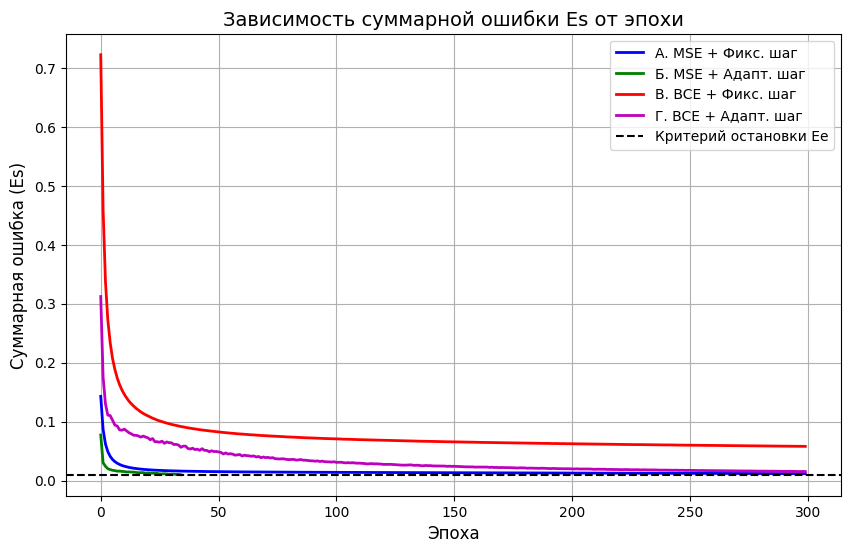

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['b', 'g', 'r', 'm']
for (name, data), color in zip(models.items(), colors):
  plt.plot(data['history'], label=name, color=color, linewidth=2)
plt.title("Зависимость суммарной ошибки Es от эпохи", fontsize=14)
plt.xlabel("Эпоха", fontsize=12)
plt.ylabel("Суммарная ошибка (Es)", fontsize=12)
plt.axhline(y=STOP_CRITERIA_E, color='k', linestyle='--', label='Критерий остановки Ee')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
print("\n--- Режим функционирования сети ---")
best_model = models["Г. BCE + Адапт. шаг"]["model"]
print("Используется модель: BCE + Адапт. шаг")

while True:
    user_input = input("Введите 6 значений (0 или 1) через пробел (или 'q' для выхода): ")
    if user_input.lower() == 'q':
        break
    try:
        x_val = list(map(int, user_input.strip().split()))
        if len(x_val) != 6 or not all(v in [0, 1] for v in x_val):
            print("Ошибка: нужно ввести ровно 6 нулей или единиц.")
            continue

        x_arr = np.array(x_val, dtype=np.float32).reshape(1, -1)
        prob = best_model.predict(x_arr)[0][0]
        pred_class = 1 if prob >= 0.5 else 0

        # Истинное значение
        true_val = 1 if sum(x_val) == 0 else 0
        status = "Совпадает с таблицей истинности" if pred_class == true_val else "Расхождение"

        print(f"Вероятность ŷ: {prob:.4f}")
        print(f"Предсказанный класс: {pred_class} (Истина: {true_val})")
        print(f"Результат: {status}\n")
    except ValueError:
        print("Ошибка ввода. Попробуйте еще раз.")


--- Режим функционирования сети ---
Используется модель: BCE + Адапт. шаг
Введите 6 значений (0 или 1) через пробел (или 'q' для выхода): 0 1 1 0 1 1
Вероятность ŷ: 0.0000
Предсказанный класс: 0 (Истина: 0)
Результат: Совпадает с таблицей истинности

Введите 6 значений (0 или 1) через пробел (или 'q' для выхода): 1 1 1 1 1 1
Вероятность ŷ: 0.0000
Предсказанный класс: 0 (Истина: 0)
Результат: Совпадает с таблицей истинности

Введите 6 значений (0 или 1) через пробел (или 'q' для выхода): q
